# CellLineSelector — Cross-Dataset Integration EDA

The per-file notebooks in `individual_eda/` each answer *"what is in this one file,
and how does it join out to the DepMap hub (df9)?"*. What none of them answers is the
question the **modelling** stage actually needs:

> When we put all the omics layers side by side,<br>
> **which cell lines can we actually train on,<br>
> how biased is that set,<br>
> do the layers agree,<br>
> and how does a research<br>
> question turn into a shortlist?**

This notebook is that missing keystone. It builds a single **ModelID-keyed presence
matrix** across every layer and uses it to answer five things:

1. **Coverage** - how many of DepMap's catalogue lines each layer covers.
2. **Catalogue gap** - omics files that reference cell lines the `df9` snapshot
   doesn't even contain (a data-release mismatch).
3. **Multi-omics intersection** - the set of lines usable by a combined model.
4. **Lineage bias** - which cancer types are under-covered (and will be mis-predicted).
5. **Source agreement** - do the two independent RNA sources (HPA vs DepMap) agree?

...and finishes with a worked **"research query -> cell-line shortlist"** example that
makes the project's *WHY* concrete.

> All joins use the canonical DepMap **ModelID** (`ACH-...`). Cross-system keys
> (ProfileID `PR-...`, Cellosaurus `CVCL_...`, CCLE `NAME_TISSUE`, GEO `GSM...`) are
> resolved through the bridge (df8) and the hub (df9). See `data/RELATIONSHIP_MAP.md`.

In [1]:
import re, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

RAW = "../../data/raw"
GE, GP = f"{RAW}/gene_expression", f"{RAW}/gene_properties"
NM, NG = f"{RAW}/nomenclature", f"{RAW}/non_gene_expression"

# Hub (df9) and bridge (df8) - the spine everything joins to
df9 = pd.read_csv(f"{NM}/9_DepMap_sample_info.csv")
df8 = pd.read_csv(f"{NM}/8_DepMap_OmicsProfiles.csv")
all_models = set(df9["DepMap_ID"])
print(f"df9 catalogue: {len(all_models)} cell lines, {df9['lineage'].nunique()} lineages")

df9 catalogue: 1840 cell lines, 30 lineages


## 1. Build the ModelID presence matrix

For every layer we reduce the file to **the set of ModelIDs it covers**, resolving
whatever ID system it uses back to `ACH-...`:

| Layer | Native key | Resolution path |
|---|---|---|
| RNA (df2) | ProfileID | df8 `Datatype=='rna'` -> ModelID |
| Mutations (df6) | ProfileID | df8 `Datatype in {wes,wgs}` -> ModelID |
| Fusions (df5) | ModelID | direct (default entry) |
| GenomeSig (df14) | ModelID | direct (default entry) |
| Proteomics (df4) | ModelID | direct (row index) |
| Metabolomics (df12) | DepMap_ID | direct |
| miRNA (df13) | CCLE_ID | df9 `CCLE_Name` -> ModelID |
| HPA-RNA (df1) | cell-line name | df11 -> CVCL -> df9 `RRID` -> ModelID |
| GEO (df3) | GSM | df10 -> CVCL -> df9 `RRID` -> ModelID |

In [2]:
# --- DepMap-native layers ---
rna_models = set(df8[df8.Datatype == "rna"]["ModelID"])
mut_pf = set(pd.read_csv(f"{GP}/6_OmicsSomaticMutationsProfile.csv", usecols=["ProfileID"], low_memory=False)["ProfileID"])
mut_models = set(df8[df8.ProfileID.isin(mut_pf) & df8.Datatype.isin(["wes","wgs"])]["ModelID"])

df5 = pd.read_csv(f"{GP}/5_OmicsFusionFilteredSupplementary.csv", usecols=["ModelID","IsDefaultEntryForModel"])
fus_models = set(df5[df5.IsDefaultEntryForModel == "Yes"]["ModelID"])

df14 = pd.read_csv(f"{NG}/14_OmicsGlobalSignatures.csv", usecols=["ModelID","IsDefaultEntryForModel"])
sig_models = set(df14[df14.IsDefaultEntryForModel == "Yes"]["ModelID"])

prot_models  = set(pd.read_csv(f"{GE}/4_Harmonized_MS_CCLE_Gygi_subsetted.csv", usecols=["Unnamed: 0"])["Unnamed: 0"])
metab_models = set(pd.read_csv(f"{NG}/12_CCLE_metabolomics_20190502.csv", usecols=["DepMap_ID"])["DepMap_ID"].dropna())

# --- layers needing a name/accession bridge ---
cvcl2model = df9.dropna(subset=["RRID"]).set_index("RRID")["DepMap_ID"].to_dict()

df11 = pd.read_csv(f"{NM}/11_hpa_rna_celline_description.tsv", sep="\t", usecols=["Cell line","Cellosaurus ID"])
hpa_models = set(df11["Cellosaurus ID"].map(cvcl2model).dropna())

gsm = {c for c in pd.read_csv(f"{GE}/3_GEOexpression.txt", sep="\t", nrows=0).columns if c.startswith("GSM")}
df10 = pd.read_csv(f"{NM}/10_GEOInfo.txt", sep="\t", usecols=["Geo_accession","Cellosaurus_ID"])
geo_cvcl = set(df10[df10.Geo_accession.isin(gsm)]["Cellosaurus_ID"].dropna())
geo_models = set(pd.Series(list(geo_cvcl)).map(cvcl2model).dropna())

mir_cols = pd.read_csv(f"{NG}/13_CCLE_miRNA_20181103.gct", sep="\t", skiprows=2, nrows=0).columns
mir_ccle = set(mir_cols) - {"Name","Description"}
mir_models = set(df9[df9.CCLE_Name.isin(mir_ccle)]["DepMap_ID"])

LAYERS = {"RNA (df2)":rna_models, "Mutations (df6)":mut_models, "Fusions (df5)":fus_models,
          "GenomeSig (df14)":sig_models, "Proteomics (df4)":prot_models,
          "Metabolomics (df12)":metab_models, "miRNA (df13)":mir_models,
          "HPA-RNA (df1)":hpa_models, "GEO (df3)":geo_models}

# boolean matrix indexed by the 1840 catalogue ModelIDs
pres = pd.DataFrame({name: df9["DepMap_ID"].isin(s).values for name, s in LAYERS.items()},
                    index=df9["DepMap_ID"])
pres.insert(0, "lineage", df9["lineage"].values)
print("presence matrix:", pres.shape)
pres.head()

presence matrix: (1840, 10)


,lineage,RNA (df2),Mutations (df6),Fusions (df5),GenomeSig (df14),Proteomics (df4),Metabolomics (df12),miRNA (df13),HPA-RNA (df1),GEO (df3)
DepMap_ID,,,,,,,,,,
ACH-000016,kidney,True,False,True,False,False,False,False,True,False
ACH-000032,blood,True,True,True,True,False,True,True,True,False
ACH-000033,lung,True,False,True,False,False,False,False,True,False
ACH-000043,fibroblast,True,True,True,True,False,False,True,True,False
ACH-000049,kidney,True,False,True,False,False,False,False,True,False


## 2. Per-layer coverage of the catalogue

How many of the 1,840 catalogue lines does each layer reach? Proteomics is the
narrowest layer by far - any model that *requires* protein data is trained on a thin
slice. The DepMap-native genomic/transcriptomic layers are the broadest.

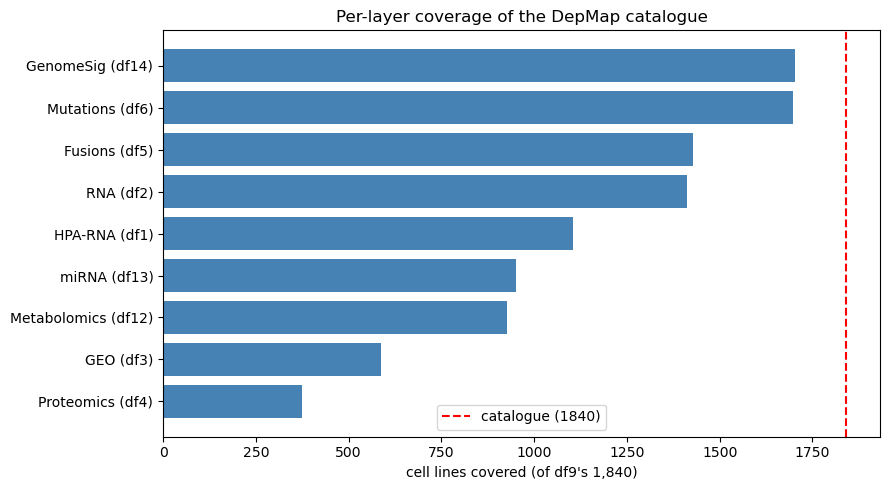

  GenomeSig (df14)      1704  (92.6%)
  Mutations (df6)       1697  (92.2%)
  Fusions (df5)         1428  (77.6%)
  RNA (df2)             1412  (76.7%)
  HPA-RNA (df1)         1104  (60.0%)
  miRNA (df13)           950  (51.6%)
  Metabolomics (df12)    927  (50.4%)
  GEO (df3)              588  (32.0%)
  Proteomics (df4)       375  (20.4%)


In [3]:
cov = {name: len(s & all_models) for name, s in LAYERS.items()}
cov = dict(sorted(cov.items(), key=lambda kv: kv[1], reverse=True))

fig, ax = plt.subplots(figsize=(9,5))
ax.barh(list(cov)[::-1], list(cov.values())[::-1], color="steelblue")
ax.axvline(len(all_models), color="red", ls="--", label=f"catalogue ({len(all_models)})")
ax.set_xlabel("cell lines covered (of df9's 1,840)")
ax.set_title("Per-layer coverage of the DepMap catalogue"); ax.legend()
plt.tight_layout(); plt.show()
for k,v in cov.items(): print(f"  {k:20s} {v:5d}  ({v/len(all_models)*100:4.1f}%)")

## 2b. Catalogue gap - omics lines the hub doesn't know about

The omics files are from a **newer DepMap release** than `9_DepMap_sample_info.csv`.
Several layers reference valid `ACH-...` ModelIDs that are **absent from df9**, so they
carry omics data but **no lineage/disease metadata** and silently drop out of any
df9-anchored join. The genomic layers (fusions, genome-signatures) have the largest
out-of-catalogue fraction. **Implication for the pipeline:** either refresh the
sample-info snapshot, or accept that these lines can't be annotated or used.

In [4]:
rows=[]
for name, s in LAYERS.items():
    raw=len(s); inside=len(s & all_models)
    rows.append((name, raw, inside, raw-inside))

gap = pd.DataFrame(rows, columns=["layer", "raw_models", "in_df9", "not_in_df9"]).sort_values("not_in_df9", ascending=False)
print(gap.to_string(index=False))
print(f"\nUnique omics ModelIDs absent from df9: ", f"{len(set().union(*LAYERS.values()) - all_models)}")

              layer  raw_models  in_df9  not_in_df9
      Fusions (df5)        1699    1428         271
   GenomeSig (df14)        1955    1704         251
          RNA (df2)        1479    1412          67
    Mutations (df6)        1744    1697          47
   Proteomics (df4)         375     375           0
Metabolomics (df12)         927     927           0
       miRNA (df13)         950     950           0
      HPA-RNA (df1)        1104    1104           0
          GEO (df3)         588     588           0

Unique omics ModelIDs absent from df9:  286


## 3. Multi-omics intersection - what can actually train

A combined model can only use cell lines present in **all** the layers it consumes.
The richest *broadly available* feature set is RNA & Mutations & Fusions & GenomeSig;
adding Proteomics collapses it to a few hundred lines.

RNA & Mut & Fus & Sig          : 1406
  + Proteomics                  : 368
  + Proteomics + Metabolomics   : 366


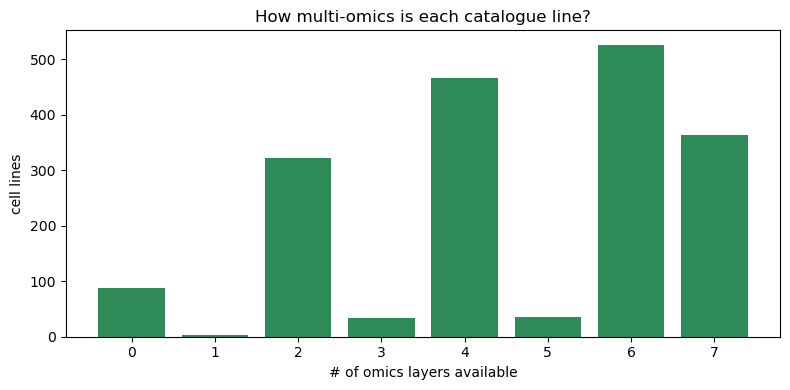

In [5]:
core = rna_models & mut_models & fus_models & sig_models
print("RNA & Mut & Fus & Sig          :", len(core))
print("  + Proteomics                  :", len(core & prot_models))
print("  + Proteomics + Metabolomics   :", len(core & prot_models & metab_models))

# how many layers does each catalogue line have?
depmap_layers = ["RNA (df2)", "Mutations (df6)", "Fusions (df5)", "GenomeSig (df14)", "Proteomics (df4)", "Metabolomics (df12)", "miRNA (df13)"]
n_layers = pres[depmap_layers].sum(axis=1)
dist = n_layers.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8,4))
ax.bar(dist.index, dist.values, color="seagreen")
ax.set_xlabel("# of omics layers available")
ax.set_ylabel("cell lines")
ax.set_title("How multi-omics is each catalogue line?")
plt.tight_layout()
plt.show()

## 4. Lineage bias - coverage per cancer type

A layer can have high overall coverage yet systematically miss certain lineages.
Those lineages will be under-represented in training and are the ones the
CellLineSelector is most likely to mis-rank. The heatmap is **% of each lineage's
catalogue lines covered by each layer** (top lineages by line count).

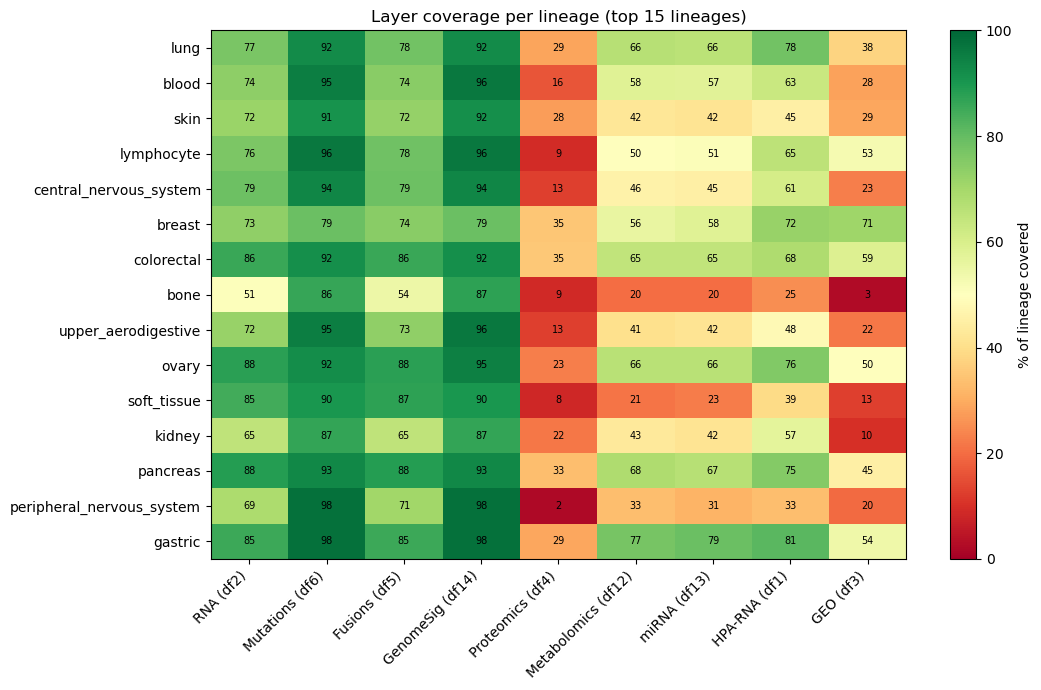

In [6]:
top_lin = df9["lineage"].value_counts().head(15).index
cov_by_lin = (pres[pres.lineage.isin(top_lin)]
              .groupby("lineage")[list(LAYERS)].mean()
              .loc[top_lin] * 100)

fig, ax = plt.subplots(figsize=(11,7))
im = ax.imshow(cov_by_lin.values, cmap="RdYlGn", vmin=0, vmax=100, aspect="auto")
ax.set_xticks(range(len(LAYERS))); ax.set_xticklabels(list(LAYERS), rotation=45, ha="right")
ax.set_yticks(range(len(top_lin))); ax.set_yticklabels(top_lin)

for i in range(cov_by_lin.shape[0]):
    for j in range(cov_by_lin.shape[1]):
        ax.text(j, i, f"{cov_by_lin.values[i,j]:.0f}", ha="center", va="center", fontsize=7)

fig.colorbar(im, label="% of lineage covered")
ax.set_title("Layer coverage per lineage (top 15 lineages)")
plt.tight_layout(); plt.show()

## 5. Do the two RNA sources agree? (df1 HPA vs df2 DepMap)

HPA (df1) and DepMap (df2) measured RNA **independently** (different labs, platforms,
units). They are *not* redundant copies - when they **agree**, that agreement is a
confidence signal that an expression value is real. We take a handful of cell lines
present in both, put HPA `nTPM` on the same `log2(x+1)` footing as DepMap's
`log2(TPM+1)`, and correlate across all shared genes.

In [ ]:
rna_pf = df8[df8.Datatype=="rna"][["ProfileID","ModelID"]].drop_duplicates("ModelID")
model2prof = dict(zip(rna_pf.ModelID, rna_pf.ProfileID))
df11m = df11.assign(model=df11["Cellosaurus ID"].map(cvcl2model)).dropna(subset=["model"])
shared = df11m[df11m.model.isin(rna_models)].drop_duplicates("model").head(8)
name2model = dict(zip(shared["Cell line"], shared["model"]))
names = set(name2model)
print("shared lines sampled:", sorted(names))

# HPA (long, large) -> pivot just these lines, chunked
parts=[]
for ch in pd.read_csv(f"{GE}/1_4_hpa_rna_celline.tsv", sep="\t", usecols=["Gene","Cell line","nTPM"], chunksize=2_000_000):
    parts.append(ch[ch["Cell line"].isin(names)])

hpa = pd.concat(parts).pivot_table(index="Gene", columns="Cell line", values="nTPM", aggfunc="mean")

# DepMap wide -> just these profiles
d2 = pd.read_csv(f"{GE}/2_DepMap_OmicsExpressionAllGenesTPMLogp1Profile.csv")
d2 = d2.rename(columns={"Unnamed: 0":"ProfileID"}).set_index("ProfileID")
d2 = d2[d2.index.isin([model2prof[m] for m in name2model.values()])]
d2.columns = [re.search(r"(ENSG\d+)", c).group(1) if re.search(r"(ENSG\d+)", c) else c
              for c in d2.columns]

cors=[]
for name, model in name2model.items():
    prof = model2prof[model]
    if prof not in d2.index: continue
    a = np.log2(hpa[name].dropna()+1); b = d2.loc[prof]
    g = a.index.intersection(b.index)
    cors.append((name, len(g), np.corrcoef(a.loc[g], b.loc[g])[0,1]))

cors_df = pd.DataFrame(cors, columns=["cell_line","n_genes","pearson_r"])

fig, ax = plt.subplots(1,2, figsize=(13,5))
ax[0].barh(cors_df.cell_line, cors_df.pearson_r, color="steelblue")
ax[0].set_xlim(0,1); ax[0].set_xlabel("Pearson r (HPA vs DepMap)")
ax[0].set_title("Per-line RNA concordance")

ex = cors_df.iloc[0].cell_line; prof = model2prof[name2model[ex]]
a = np.log2(hpa[ex].dropna()+1); b = d2.loc[prof]; g = a.index.intersection(b.index)
ax[1].scatter(a.loc[g], b.loc[g], s=4, alpha=0.2, color="darkorange")
ax[1].set_xlabel("HPA log2(nTPM+1)")
ax[1].set_ylabel("DepMap log2(TPM+1)")
ax[1].set_title(f"{ex}: gene-level agreement")
plt.tight_layout()
plt.show()

print(cors_df.to_string(index=False))

shared lines sampled: ['143B', '22Rv1', '23132/87', '253J', '253J-BV', '42-MG-BA', '5637', '59M']


## 6. Expression-source overlap - does HPA/GEO add new cell lines?

DepMap RNA (df2) is the primary expression matrix. HPA (df1) and GEO (df3) are worth
the messy multi-hop joins only if they reach lines df2 **doesn't** have.

In [ ]:
rna_in = rna_models & all_models
hpa_in = hpa_models & all_models
geo_in = geo_models & all_models
print(f"DepMap RNA (df2)         : {len(rna_in)} lines")
print(f"HPA new beyond df2       : {len(hpa_in - rna_in)}")
print(f"GEO new beyond df2       : {len(geo_in - rna_in)}")
print(f"HPA or GEO new beyond df2: {len((hpa_in | geo_in) - rna_in)}")
print(f"covered by all three     : {len(rna_in & hpa_in & geo_in)}")

## 7. From research question to shortlist - a worked *WHY*

The deliverable is a **top-10 shortlist with a justification**. The presence matrix
plus the omics tables are exactly what turns a query into candidates. Example query:

> *"A drug targeting **EGFR** in **lung** cancer."*

Selection logic: restrict to the lung lineage -> keep lines with RNA data -> rank by
**EGFR expression** (the drug needs its target present) -> flag lines that also carry
an **EGFR mutation** (a precision-medicine match - the strongest *why*).

In [ ]:
lung = df9[df9.lineage.astype(str).str.contains("lung", case=False)][["DepMap_ID","cell_line_name"]]
lung = lung[lung.DepMap_ID.isin(rna_models)].copy()

# EGFR expression from df2
egcol = [c for c in pd.read_csv(f"{GE}/2_DepMap_OmicsExpressionAllGenesTPMLogp1Profile.csv", nrows=0).columns if c.startswith("EGFR (")][0]
e = pd.read_csv(f"{GE}/2_DepMap_OmicsExpressionAllGenesTPMLogp1Profile.csv", usecols=["Unnamed: 0", egcol]).rename(columns={"Unnamed: 0":"ProfileID", egcol:"EGFR_log2TPM"})
prof2model = dict(zip(rna_pf.ProfileID, rna_pf.ModelID))
e["DepMap_ID"] = e.ProfileID.map(prof2model)
lung = lung.merge(e[["DepMap_ID","EGFR_log2TPM"]], on="DepMap_ID", how="left")

# EGFR mutation status from df6
mut = pd.read_csv(f"{GP}/6_OmicsSomaticMutationsProfile.csv", usecols=["ProfileID","HugoSymbol","ProteinChange"], low_memory=False)
egfr_pf = mut[mut.HugoSymbol == "EGFR"]["ProfileID"]
egfr_models = set(df8[df8.ProfileID.isin(egfr_pf)]["ModelID"])
lung["EGFR_mutation"] = lung.DepMap_ID.isin(egfr_models)

shortlist = lung.sort_values("EGFR_log2TPM", ascending=False).head(10)
print("Top-10 lung candidates for an EGFR-targeted drug:")
print(shortlist.to_string(index=False))

## 8. Reconciliation & takeaways

- **Reconciles with the pipeline:** the preprocessed `pipeline_v0` cell-line counts
  match the raw layer sets here (within the catalogue-gap noted in section 2b).
- **Coverage is uneven:** proteomics (~375) is the binding constraint for any
  protein-dependent model; the broad genomic/transcriptomic layers cover ~1,400+.
- **Catalogue gap is real:** hundreds of omics ModelIDs aren't in the df9 snapshot -
  refresh sample-info or exclude them explicitly.
- **Lineage bias exists** and must be reported alongside any shortlist, or rare
  cancers get silently under-served.
- **The two RNA sources agree strongly** (r ~ 0.96-0.98), so HPA can be trusted as a
  fallback/confidence check - but it adds few *new* lines beyond DepMap.
- **The WHY is mechanical:** query -> lineage filter -> target-expression rank ->
  mutation flag. This is the backbone the modelling + RAG stages formalise.

In [ ]:
man = json.load(open("../../data/preprocessed/pipeline_v0/manifest.json"))["layers"]
print("layer            raw-set   manifest n_cell_lines")

for name, key in [
    ("RNA (df2)", "rna_expression"), ("Mutations (df6)", "mutations"),
    ("Fusions (df5)","fusions"), ("GenomeSig (df14)", "genome_signatures")]:
    print(f"  {name:16s} {len(LAYERS[name]):6d}   {man[key]['n_cell_lines']:6d}")

print(f"  {'cell_line_index':16s} {len(all_models):6d}   {man['cell_line_index']['n_cell_lines']:6d}")

## In Plain English — What This Notebook Means & Where It Goes Next

### 1. What this notebook actually is (layman terms)
The 14 individual notebooks each looked at **one** dataset in isolation. **This notebook is where they all come together.** Its job is to answer the one question those separate notebooks couldn't: *"If we line every dataset up against the master list of cell lines, which cell lines actually have enough data to be used — and which can be measured together?"*

The trick it uses is a **presence matrix** (i.e., a big yes/no checklist): a table with **1,840 cell lines down the side** and **9 data layers across the top** (RNA, mutations, fusions, genome scores, proteins, metabolites, miRNA, and the two older expression sources). Each box is simply ticked "yes, this cell line has this kind of data" or "no, it doesn't." From that one checklist, everything else follows.

### 2. What we found, and the next steps
What the notebook showed:
- **Everything joins onto one ID** — the DepMap `ModelID` (`ACH-…`). Datasets that label their data differently are translated onto this single spine using the bridge/dictionary files. **This confirms the project can combine all 14 datasets without losing meaning** — the core requirement.
- **Coverage is very uneven.** The genome/DNA-based layers reach ~1,400–1,950 cell lines, but **proteomics reaches only 375 (~20%)** — so proteins are the *bottleneck*: insist on protein data and the usable set collapses to 375.
- **286 cell lines referenced by the omics files don't exist in the master catalogue** (a data-release version mismatch) — mostly from fusions and genome scores. These "orphans" must be **explicitly excluded or the catalogue refreshed**, or joins will silently drop them.
- **Some cancer types are systematically under-covered** (the lineage heatmap) — any model must *report* this bias so researchers know which tissues it's weak on.
- **The two independent RNA sources agree strongly** (correlation ~0.96–0.98), so they can be trusted and used as fallbacks for each other.
- A **worked example** ("a drug targeting EGFR in lung cancer") shows the whole point end-to-end: filter to lung → keep lines with RNA → rank by EGFR activity → flag EGFR mutations → return a top-10 shortlist with the *reason* each line was picked.

Next steps:
- **Lock in the core trainable set**: the ~1,400 lines that have RNA + mutations + fusions + genome scores; treat proteins/metabolites/miRNA as **optional enrichment** so the model still works when they're absent.
- **Decide the orphan-handling rule** (drop the 286, or refresh the catalogue) and apply it consistently in the preprocessing pipeline.
- **Carry the lineage-bias table forward** as a reportable limitation / a frontend warning.

Still missing: this notebook validates *coverage and joins* but does **no feature engineering** — turning each layer into model-ready columns (burden counts, driver flags, variance-filtered genes) still happens in the preprocessing pipeline.

### 3. Which ML approach fits
This notebook is the **blueprint for the ranking system itself**, and it points to a **hybrid**, not a single algorithm:
- **Rule/filter + score ranking** (as in the EGFR example): filter by lineage and required target genes, then **rank** lines by how well they match the include/exclude gene request. This is the most interpretable backbone and directly delivers the "top 5–10 with reasons" output.
- **Unsupervised similarity** (clustering / nearest-neighbours on the omics profiles) to power "find me cell lines like this one."
- A **supervised** layer is only as good as its labels — and this notebook shows the labels (lineage/disease) live in the master catalogue, while many lines lack full data. So supervised models should be trained on the ~1,400-line core and **degrade gracefully** for lines missing layers.

> **Big-picture note:** This is the keystone that turns 14 separate files into one coherent, queryable system. The DepMap `ModelID` spine + the presence matrix are what make a *single* model over all the data biologically valid.